# PENGEMBANGAN MODEL RANDOM FOREST BERBASIS EXPLAINABLE AI UNTUK DETEKSI ANCAMAN PHISHING PADA UNIFORM RESOURCE LOCATOR

**Alur metodologi penelitian:** Business & Data Understanding -> Data Preparation -> Modelling & Evaluation -> Interpretation (SHAP) -> Deployment -> Operational & Documentation.


## Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import time
import warnings
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import shap
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print("Versi library -> pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__, "| shap", shap.__version__)

Versi library -> pandas 3.0.5 | numpy 2.4.6 | scikit-learn 1.9.0 | shap 0.51.0


## Pengumpulan & Penggabungan Dataset 

Dua sumber data digabungkan:
- **Kaggle** — dataset *Malicious and Benign URLs*, memuat URL berkategori `legitimate`, `phishing`, `defacement`, dan `malware`.
- **PhishTank** — kumpulan URL *phishing* yang telah diverifikasi komunitas keamanan siber.

Label biner dibuat: **0 = legitimate**, **1 = phishing**. Kategori `defacement` dan `malware` dibuang karena fokus penelitian ini adalah klasifikasi biner phishing vs legitimate.

In [2]:
kaggle = pd.read_csv("dataset_kaggle.csv")
phishtank = pd.read_csv("dataset_phishtank.csv")

kaggle["source"] = "Kaggle"
phishtank["source"] = "PhishTank"

dataset = pd.concat(
    [kaggle, phishtank],
    ignore_index=True
)

print("JUMLAH DATA AWAL (SEBELUM PREPROCESSING)")
print("Jumlah data Kaggle    :", len(kaggle))
print("Jumlah data PhishTank :", len(phishtank))
print("Total gabungan data   :", len(dataset))
print("===========================================\n")

dataset = dataset.drop_duplicates(subset="url")

print("JUMLAH SETELAH DROP DUPLICATE")
print(dataset["source"].value_counts())
print("Total gabungan data   :", len(dataset))
print("===========================================\n")

dataset["label"] = dataset["type"].map({
    "legitimate": 0,
    "phishing": 1
})

print("Kategori pada kolom 'type':")
print(dataset["type"].value_counts())
print("Total :", len(dataset))
print("\nJumlah baris dengan label NaN (kategori selain legitimate/phishing):",
      dataset["label"].isna().sum())

dataset = dataset.dropna(subset=["label"]).reset_index(drop=True)
dataset["label"] = dataset["label"].astype(int)

print("\nUkuran dataset akhir:", dataset.shape)
pd.concat([dataset.head(3), dataset.tail(3)])

JUMLAH DATA AWAL (SEBELUM PREPROCESSING)
Jumlah data Kaggle    : 65535
Jumlah data PhishTank : 65628
Total gabungan data   : 131163

JUMLAH SETELAH DROP DUPLICATE
source
PhishTank    65625
Kaggle       64904
Name: count, dtype: int64
Total gabungan data   : 130529

Kategori pada kolom 'type':
type
phishing      69530
legitimate    48078
defacement    11960
malware         961
Name: count, dtype: int64
Total : 130529

Jumlah baris dengan label NaN (kategori selain legitimate/phishing): 12921

Ukuran dataset akhir: (117608, 4)


,url,type,source,label
0,br-icloud.com.br,phishing,Kaggle,1
1,mp3raid.com/music/krizz_kaliko.html,legitimate,Kaggle,0
2,bopsecrets.org/rexroth/cr/1.htm,legitimate,Kaggle,0
117605,http://www.formbuddy.com/cgi-bin/formdisp.pl?u...,phishing,PhishTank,1
117606,http://www.habbocreditosparati.blogspot.com/,phishing,PhishTank,1
117607,http://creditiperhabbogratissicuro100.blogspot...,phishing,PhishTank,1


In [3]:
# Ambil 5 baris legitimate
legit_sample = kaggle[kaggle["type"] == "legitimate"].head(5)
print("=== 5 Contoh URL Legitimate (Kaggle) ===")
print(legit_sample)

print()

# Ambil 5 baris phishing
phishing_sample = kaggle[kaggle["type"] == "phishing"].head(5)
print("=== 5 Contoh URL Phishing (Kaggle) ===")
print(phishing_sample)

=== 5 Contoh URL Legitimate (Kaggle) ===
                                                 url        type  source
1                mp3raid.com/music/krizz_kaliko.html  legitimate  Kaggle
2                    bopsecrets.org/rexroth/cr/1.htm  legitimate  Kaggle
5  http://buzzfil.net/m/show-art/ils-etaient-loin...  legitimate  Kaggle
6      espn.go.com/nba/player/_/id/3457/brandon-rush  legitimate  Kaggle
7     yourbittorrent.com/?q=anthony-hamilton-soulife  legitimate  Kaggle

=== 5 Contoh URL Phishing (Kaggle) ===
                                                  url      type  source
0                                    br-icloud.com.br  phishing  Kaggle
21         signin.eby.de.zukruygxctzmmqi.civpro.co.za  phishing  Kaggle
28  http://www.marketingbyinternet.com/mo/e56508df...  phishing  Kaggle
40  https://docs.google.com/spreadsheet/viewform?f...  phishing  Kaggle
72                               retajconsultancy.com  phishing  Kaggle


## Eksplorasi Data (EDA)

            Jumlah Data  Persentase (%)
label                                  
Phishing          69530           59.12
Legitimate        48078           40.88

Total data: 117608


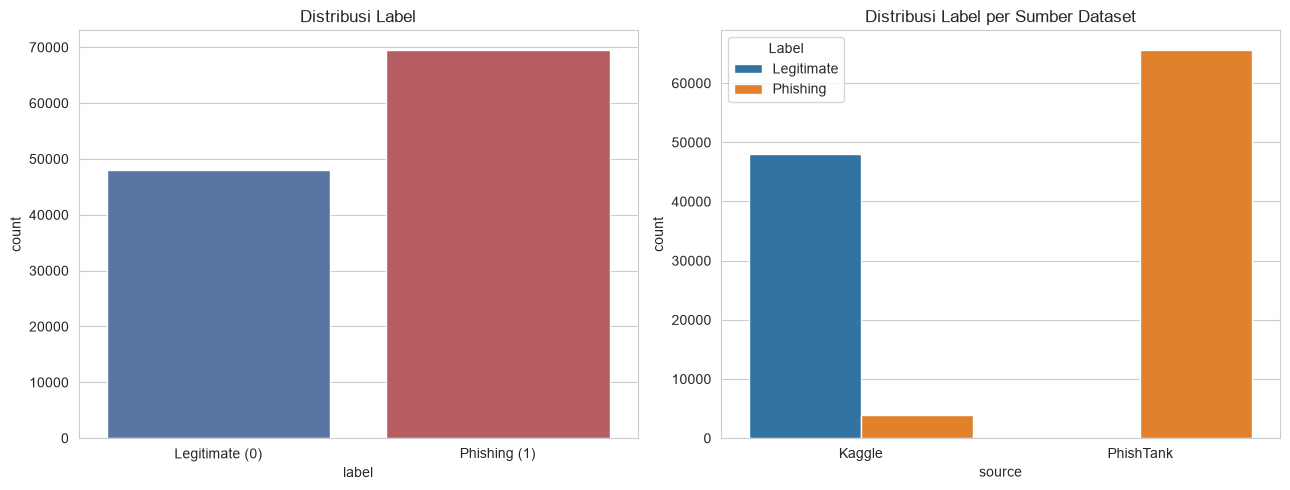

In [4]:
dist = dataset["label"].value_counts().rename({0: "Legitimate", 1: "Phishing"})
dist_pct = (dist / dist.sum() * 100).round(2)
print(pd.DataFrame({"Jumlah Data": dist, "Persentase (%)": dist_pct}))
print("\nTotal data:", dataset.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=dataset, x="label", hue="label", ax=axes[0], palette=["#4C72B0", "#C44E52"], legend=False)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Legitimate (0)", "Phishing (1)"])
axes[0].set_title("Distribusi Label")
sns.countplot(data=dataset, x="source", hue="label", ax=axes[1])
axes[1].set_title("Distribusi Label per Sumber Dataset")
axes[1].legend(title="Label", labels=["Legitimate", "Phishing"])
plt.tight_layout()
plt.show()

## Ekstraksi Fitur Leksikal URL

Setiap URL ditransformasikan menjadi 14 fitur numerik yang mencakup karakteristik leksikal (panjang & frekuensi karakter), struktural (subdomain, pengulangan domain), dan indikator keamanan/penyamaran (protokol HTTPS, string acak).

In [5]:
def get_hostname(url):
    """Mengambil hostname (tanpa userinfo & port) dari sebuah URL."""
    url = str(url)
    parsed = urlparse(url if "://" in url else "http://" + url)
    hostname = parsed.netloc if parsed.netloc else url.split("/")[0]
    hostname = hostname.split("@")[-1]
    hostname = hostname.split(":")[0]
    return hostname.lower()

def get_domain_name(hostname):
    """Mengambil nama domain level-2 (tanpa subdomain & TLD)."""
    parts = hostname.split(".")
    if len(parts) >= 2:
        return parts[-2]
    return hostname

def is_random_string(s):
    """Heuristik RandomString: rasio vokal rendah / rangkaian konsonan panjang."""
    s = re.sub(r"[^a-zA-Z]", "", s)
    if len(s) < 4:
        return 0
    vowels = sum(1 for c in s.lower() if c in "aeiou")
    ratio = vowels / len(s)
    consonant_runs = re.findall(r"[^aeiou\d_]+", s.lower())
    max_run = max((len(r) for r in consonant_runs), default=0)
    return 1 if (ratio < 0.2 or max_run >= 5) else 0

def infer_no_https(url):
    """Menentukan nilai fitur NoHttps (1 = tanpa HTTPS, 0 = HTTPS)."""
    # skema tidak dituliskan -> diasumsikan HTTPS (bukan diasumsikan tidak aman),
    # untuk menghindari kebocoran informasi asal sumber data (Kaggle vs PhishTank)
    u = url.lower()
    if u.startswith("https://"):
        return 0
    if u.startswith("http://"):
        return 1
    return 0  # skema tidak dituliskan -> asumsikan HTTPS

def extract_features_14(url):
    """Mengekstrak 14 fitur URL."""
    url = str(url).strip()
    parsed = urlparse(url if "://" in url else "http://" + url)
    hostname = get_hostname(url)
    path = parsed.path
    query = parsed.query
    domain_name = get_domain_name(hostname)

    host_parts = hostname.split(".")
    subdomain_part = ".".join(host_parts[:-2]) if len(host_parts) > 2 else ""

    feats = {}
    feats["UrlLength"] = len(url)
    feats["NumDots"] = url.count(".")
    feats["SubdomainLevel"] = max(hostname.count(".") - 1, 0)
    feats["NumDash"] = url.count("-")
    feats["NumUnderscore"] = url.count("_")
    feats["NumPercent"] = url.count("%")
    feats["NumQueryComponents"] = len([q for q in query.split("&") if q != ""]) if query else 0
    feats["NumAmpersand"] = url.count("&")
    feats["RandomString"] = is_random_string(domain_name)
    feats["NoHttps"] = infer_no_https(url)
    feats["DomainInPaths"] = 1 if domain_name and domain_name in path.lower() else 0
    feats["DomainInSubdomains"] = 1 if domain_name and domain_name in subdomain_part.lower() else 0
    feats["HTTPSInHostname"] = 1 if "https" in hostname else 0
    feats["HostnameLength"] = len(hostname)
    return feats

FEATURE_ORDER = [
    "UrlLength", "NumDots", "SubdomainLevel", "NumDash", "NumUnderscore",
    "NumPercent", "NumQueryComponents", "NumAmpersand", "RandomString",
    "NoHttps", "DomainInPaths", "DomainInSubdomains", "HTTPSInHostname",
    "HostnameLength",
]

print(extract_features_14("http://verify-secure-login.tk/account/update?id=123&x=1"))
print(extract_features_14("https://https-paypal-secure.verify-account123.com/login"))

{'UrlLength': 55, 'NumDots': 1, 'SubdomainLevel': 0, 'NumDash': 2, 'NumUnderscore': 0, 'NumPercent': 0, 'NumQueryComponents': 2, 'NumAmpersand': 1, 'RandomString': 0, 'NoHttps': 1, 'DomainInPaths': 0, 'DomainInSubdomains': 0, 'HTTPSInHostname': 0, 'HostnameLength': 22}
{'UrlLength': 55, 'NumDots': 2, 'SubdomainLevel': 1, 'NumDash': 3, 'NumUnderscore': 0, 'NumPercent': 0, 'NumQueryComponents': 0, 'NumAmpersand': 0, 'RandomString': 0, 'NoHttps': 0, 'DomainInPaths': 0, 'DomainInSubdomains': 0, 'HTTPSInHostname': 1, 'HostnameLength': 41}


In [6]:
feature_df = dataset["url"].apply(lambda u: pd.Series(extract_features_14(u)))
data_final = pd.concat([dataset[["url", "label"]], feature_df], axis=1)

n_missing = data_final.isnull().sum().sum()
print("Ukuran data setelah ekstraksi fitur:", data_final.shape)
print("Jumlah missing value:", n_missing)

# Penanganan eksplisit apabila ekstraksi fitur menghasilkan missing value
# (mis. URL dengan format tidak wajar yang gagal diparsing sebagian).
if n_missing > 0:
    print("\nKolom dengan missing value:")
    print(data_final.isnull().sum()[data_final.isnull().sum() > 0])
    data_final = data_final.dropna().reset_index(drop=True)
    print("\nUkuran data setelah baris ber-missing-value dibuang:", data_final.shape)
else:
    print("Tidak ditemukan missing value pada fitur hasil ekstraksi — data siap digunakan.")

data_final.head()

Ukuran data setelah ekstraksi fitur: (117608, 16)
Jumlah missing value: 0
Tidak ditemukan missing value pada fitur hasil ekstraksi — data siap digunakan.


,url,label,UrlLength,NumDots,SubdomainLevel,NumDash,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,RandomString,NoHttps,DomainInPaths,DomainInSubdomains,HTTPSInHostname,HostnameLength
0,br-icloud.com.br,1,16,2,1,1,0,0,0,0,0,0,0,0,0,16
1,mp3raid.com/music/krizz_kaliko.html,0,35,2,0,0,1,0,0,0,0,0,0,0,0,11
2,bopsecrets.org/rexroth/cr/1.htm,0,31,2,0,0,0,0,0,0,0,0,0,0,0,14
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,0,118,2,0,16,0,0,0,0,0,1,0,0,0,11
4,espn.go.com/nba/player/_/id/3457/brandon-rush,0,45,2,1,1,1,0,0,0,0,0,0,0,0,11


### Studi Kasus: Menemukan & Memperbaiki Kebocoran Data (Data Leakage) pada Fitur `NoHttps`

Pada iterasi awal implementasi, fitur `NoHttps` dihitung dengan asumsi sederhana: jika URL tidak menuliskan skema protokol, maka diasumsikan `http` (tidak aman). Pengecekan distribusi fitur ini per sumber data mengungkap masalah serius:

In [7]:
feats_check = dataset["url"].apply(lambda u: 0 if str(u).lower().startswith("https://") else 1)
check_df = dataset.copy()
check_df["NoHttps_naif"] = feats_check
print("Distribusi NoHttps (asumsi naif: skema kosong -> http) per sumber & label:")
print(check_df.groupby(["source", "label"])["NoHttps_naif"].mean().round(3))

Distribusi NoHttps (asumsi naif: skema kosong -> http) per sumber & label:
source     label
Kaggle     0        0.995
           1        0.994
PhishTank  1        0.070
Name: NoHttps_naif, dtype: float64


In [8]:
print("Distribusi NoHttps (setelah perbaikan) per sumber & label:")
print(data_final.join(dataset["source"]).groupby(["source", "label"])["NoHttps"].mean().round(3))

Distribusi NoHttps (setelah perbaikan) per sumber & label:
source     label
Kaggle     0        0.088
           1        0.314
PhishTank  1        0.070
Name: NoHttps, dtype: float64


### Korelasi fitur terhadap Label

Korelasi setiap fitur terhadap label:
SubdomainLevel        0.383
HostnameLength        0.239
NumDash              -0.202
NumDots               0.145
NumUnderscore        -0.117
NumAmpersand          0.075
NumQueryComponents    0.064
NumPercent           -0.061
DomainInPaths        -0.035
UrlLength             0.015
HTTPSInHostname       0.010
RandomString          0.008
NoHttps              -0.006
DomainInSubdomains   -0.001
Name: label, dtype: float64


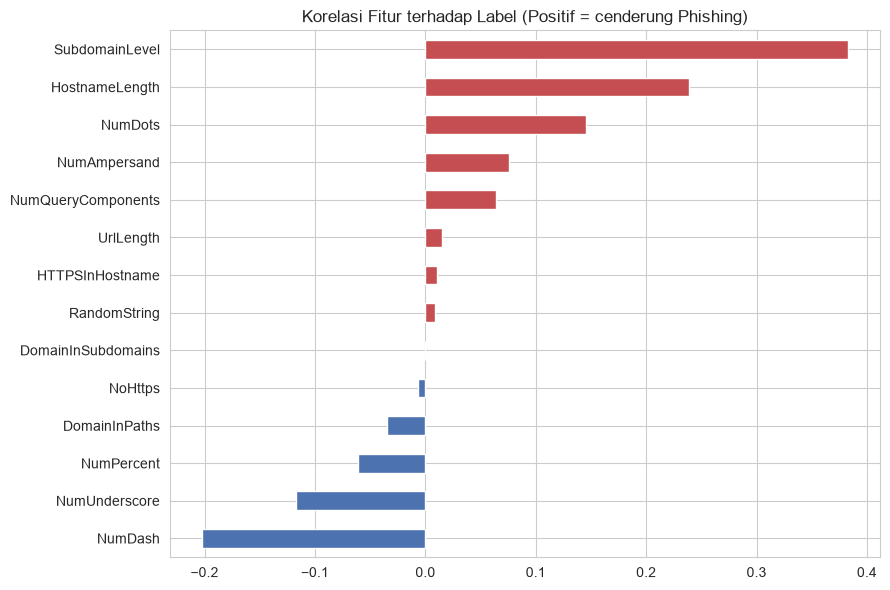

In [9]:
corr = data_final.drop(columns=["url"]).corr()["label"].drop("label").sort_values(key=abs, ascending=False)
print("Korelasi setiap fitur terhadap label:")
print(corr.round(3))

plt.figure(figsize=(9, 6))
corr.sort_values().plot.barh(color=["#C44E52" if v > 0 else "#4C72B0" for v in corr.sort_values()])
plt.title("Korelasi Fitur terhadap Label (Positif = cenderung Phishing)")
plt.tight_layout()
plt.show()

## Preprocessing, Split Data & Pemodelan Random Forest 

Karena Random Forest bekerja berdasarkan pembagian nilai (threshold split) pada setiap node, normalisasi/scaling fitur tidak diperlukan. Dataset dibagi menjadi 70% data latih, 15% data validasi, dan 15% data uji dengan stratifikasi kelas.

In [10]:
feature_cols = FEATURE_ORDER
X = data_final[feature_cols]
y = data_final["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("Data latih   :", X_train.shape)
print("Data validasi:", X_val.shape)
print("Data uji     :", X_test.shape)

ratio = y_train.value_counts(normalize=True)
print("\nRasio kelas pada data latih:\n", ratio.round(3))

Data latih   : (82325, 14)
Data validasi: (17641, 14)
Data uji     : (17642, 14)

Rasio kelas pada data latih:
 label
1    0.591
0    0.409
Name: proportion, dtype: float64


Pencarian hyperparameter terbaik dilakukan dengan `GridSearchCV` (5-fold cross-validation, metrik F1-score):

In [11]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
}

t0 = time.time()
grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f"\nWaktu pencarian: {time.time() - t0:.1f} detik")
print("Parameter terbaik:", grid.best_params_)
print("F1-score CV terbaik:", grid.best_score_)

model = grid.best_estimator_
model

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Waktu pencarian: 132.1 detik
Parameter terbaik: {'max_depth': 20, 'n_estimators': 200}
F1-score CV terbaik: 0.946394156438976


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

### Verifikasi Perhitungan Manual Random Forest *(Persamaan 1, Sub-bab 4.3.4)*

Probabilitas akhir Random Forest adalah rata-rata probabilitas seluruh pohon. Sel berikut menghitung rata-rata itu secara manual dan membandingkannya dengan `predict_proba()`.

In [12]:
# Sampel uji
sample_url = "https://www.bbc.com/news"
x_row = pd.DataFrame([extract_features_14(sample_url)])[feature_cols]

# Mengambil prediksi probabilitas dari setiap pohon secara individual
tree_probas = np.array([tree.predict_proba(x_row)[0] for tree in model.estimators_])

# Menghitung rata-rata manual sesuai Persamaan (1)
manual_avg = tree_probas.mean(axis=0)

print(manual_avg)                                              # [P(Legitimate), P(Phishing)]
print(model.predict_proba(x_row)[0])                            # nilainya harus sama dengan baris di atas
print(np.allclose(manual_avg, model.predict_proba(x_row)[0]))   # harus True

print("\nProbabilitas kelas Phishing dari 10 pohon pertama:")
for i in range(10):
    print(f"  Pohon {i+1:>3}: {tree_probas[i][1]:.4f}")

[0.43073336 0.56926664]
[0.43073336 0.56926664]
True

Probabilitas kelas Phishing dari 10 pohon pertama:
  Pohon   1: 0.5333
  Pohon   2: 0.8750
  Pohon   3: 0.6667
  Pohon   4: 0.3333
  Pohon   5: 0.5294
  Pohon   6: 1.0000
  Pohon   7: 1.0000
  Pohon   8: 0.8367
  Pohon   9: 0.8571
  Pohon  10: 0.5909


In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

Accuracy  : 0.9387
Precision : 0.9649
Recall    : 0.9302
F1-score  : 0.9472
ROC-AUC   : 0.9849

              precision    recall  f1-score   support

  Legitimate       0.90      0.95      0.93      7212
    Phishing       0.96      0.93      0.95     10430

    accuracy                           0.94     17642
   macro avg       0.93      0.94      0.94     17642
weighted avg       0.94      0.94      0.94     17642



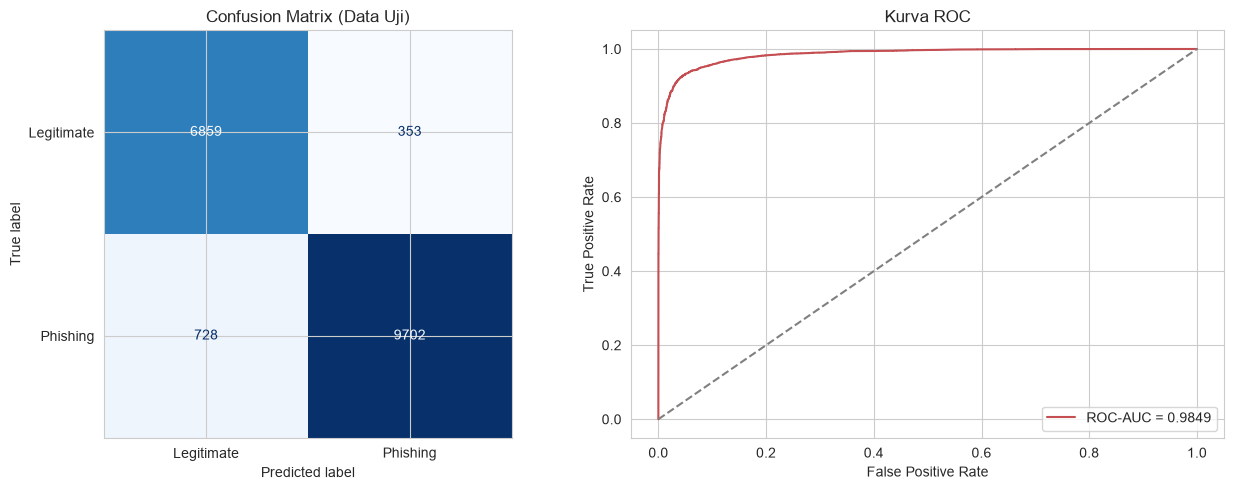

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Phishing"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (Data Uji)")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}", color="#C44E52")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Kurva ROC"); axes[1].legend()

plt.tight_layout()
plt.show()

### Verifikasi Manual Metrik Evaluasi *(Persamaan 4-7, Sub-bab 4.5.1)*

In [15]:
# Verifikasi manual metrik evaluasi (Persamaan 4-7, Tabel 12 pada Bab IV)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN = {tn:,} | FP = {fp:,} | FN = {fn:,} | TP = {tp:,} | total = {tn+fp+fn+tp:,}")

acc_m  = (tp + tn) / (tp + tn + fp + fn)
prec_m = tp / (tp + fp)
rec_m  = tp / (tp + fn)
f1_m   = 2 * prec_m * rec_m / (prec_m + rec_m)

print(f"Accuracy  manual = {acc_m:.4f} | sklearn = {acc:.4f}")
print(f"Precision manual = {prec_m:.4f} | sklearn = {prec:.4f}")
print(f"Recall    manual = {rec_m:.4f} | sklearn = {rec:.4f}")
print(f"F1-score  manual = {f1_m:.4f} | sklearn = {f1:.4f}")
assert np.allclose([acc_m, prec_m, rec_m, f1_m], [acc, prec, rec, f1]), "Metrik manual tidak sama dengan sklearn"
print("Keempat metrik manual identik dengan sklearn.")


TN = 6,859 | FP = 353 | FN = 728 | TP = 9,702 | total = 17,642
Accuracy  manual = 0.9387 | sklearn = 0.9387
Precision manual = 0.9649 | sklearn = 0.9649
Recall    manual = 0.9302 | sklearn = 0.9302
F1-score  manual = 0.9472 | sklearn = 0.9472
Keempat metrik manual identik dengan sklearn.


### Evaluasi terhadap Kriteria Minimum *(Keputusan Iterasi Modelling)*

Sesuai alur *Modelling & Evaluation* pada metodologi penelitian, hasil evaluasi model dibandingkan terhadap kriteria performa minimum yang ditetapkan. Jika kriteria belum terpenuhi, proses **kembali ke tahap Grid Search/Modelling** (mis. memperluas `param_grid`, menambah data, atau merekayasa ulang fitur) sebelum berlanjut ke tahap interpretasi dan deployment.

In [16]:
# Kriteria performa minimum yang ditetapkan pada penelitian ini
MIN_ACCURACY = 0.90
MIN_F1 = 0.90
MIN_AUC = 0.90

criteria = {
    "Accuracy": (acc, MIN_ACCURACY),
    "F1-score": (f1, MIN_F1),
    "ROC-AUC": (auc, MIN_AUC),
}

print("=== Pengecekan Kriteria Minimum Model ===")
all_passed = True
for metric_name, (value, threshold) in criteria.items():
    status = "LOLOS" if value >= threshold else "BELUM LOLOS"
    if value < threshold:
        all_passed = False
    print(f"{metric_name:10s}: {value:.4f}  (minimum {threshold:.2f}) -> {status}")

if all_passed:
    print("\n>>> Model memenuhi seluruh kriteria minimum. Lanjut ke tahap Interpretation (SHAP).")
else:
    print("\n>>> Model BELUM memenuhi seluruh kriteria minimum.")
    print(">>> Sesuai alur penelitian, proses perlu KEMBALI ke tahap Modelling:")
    print("    - Perluas param_grid pada GridSearchCV, dan/atau")
    print("    - Tambah/kaya-kan fitur atau volume data latih, dan/atau")
    print("    - Evaluasi ulang kualitas data (lihat Bagian 4).")

=== Pengecekan Kriteria Minimum Model ===
Accuracy  : 0.9387  (minimum 0.90) -> LOLOS
F1-score  : 0.9472  (minimum 0.90) -> LOLOS
ROC-AUC   : 0.9849  (minimum 0.90) -> LOLOS

>>> Model memenuhi seluruh kriteria minimum. Lanjut ke tahap Interpretation (SHAP).


> **Tujuan 1 tercapai:** model Random Forest berhasil dibangun dengan performa tinggi pada data uji (F1-score & ROC-AUC ditampilkan di atas), menggunakan fitur-fitur leksikal, struktural, dan indikator keamanan URL yang telah dianalisis pada Bagian 4.

## Interpretasi Model dengan SHAP 

Karena Random Forest bersifat *black-box*, teknik **SHAP (SHapley Additive exPlanations)** diterapkan untuk menjelaskan kontribusi setiap fitur terhadap prediksi model, baik secara **global** (pola umum model) maupun **lokal** (penjelasan untuk satu URL spesifik).

In [17]:
explainer = shap.TreeExplainer(model)

X_sample = X_test.sample(n=500, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_phishing = shap_values[1]
else:
    shap_values_phishing = shap_values[:, :, 1]

# Nilai dasar (base value / expected value) untuk kelas Phishing (1)
base_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# Objek shap.Explanation (API modern) — dipakai untuk seluruh plot pada bagian ini
shap_explanation = shap.Explanation(
    values=shap_values_phishing,
    base_values=np.repeat(base_value, X_sample.shape[0]),
    data=X_sample.values,
    feature_names=feature_cols,
)

print("Jumlah sampel untuk interpretasi SHAP :", X_sample.shape[0])
print("Bentuk (shape) SHAP values            :", shap_values_phishing.shape)
print("Base value (expected value) kelas Phishing:", round(float(base_value), 4))

Jumlah sampel untuk interpretasi SHAP : 500
Bentuk (shape) SHAP values            : (500, 14)
Base value (expected value) kelas Phishing: 0.5


### Verifikasi Manual Nilai Shapley dan Additivity *(Persamaan 2-3, Sub-bab 4.4)*

Sel pertama menghitung nilai Shapley contoh 3 fitur (Tabel 8 dan 9 pada Bab IV) secara brute-force. Sel kedua memeriksa sifat additivity SHAP pada model sebenarnya (Tabel 10 pada Bab IV).

In [18]:
# Simulasi Shapley 3 fitur hipotetis {A, B, C} (Tabel 8 -> Tabel 9 pada Bab IV)
from itertools import combinations
from math import factorial

val = {
    frozenset(): 0.50,
    frozenset("A"): 0.60, frozenset("B"): 0.55, frozenset("C"): 0.52,
    frozenset("AB"): 0.68, frozenset("AC"): 0.64, frozenset("BC"): 0.58,
    frozenset("ABC"): 0.70,
}
players = ["A", "B", "C"]
p = len(players)

def shapley(i):
    others = [x for x in players if x != i]
    total = 0.0
    for r in range(len(others) + 1):
        for S in combinations(others, r):
            S = frozenset(S)
            w = factorial(len(S)) * factorial(p - len(S) - 1) / factorial(p)
            total += w * (val[S | {i}] - val[S])
    return total

phi = {i: shapley(i) for i in players}
for i in players:
    print(f"phi_{i} = {phi[i]:.4f}")
print(f"Total = {sum(phi.values()):.4f}  |  Val(ABC) - Val(kosong) = {val[frozenset('ABC')] - val[frozenset()]:.4f}")
assert abs(sum(phi.values()) - (val[frozenset('ABC')] - val[frozenset()])) < 1e-9


phi_A = 0.1150
phi_B = 0.0600
phi_C = 0.0250
Total = 0.2000  |  Val(ABC) - Val(kosong) = 0.2000


In [19]:
# Verifikasi additivity SHAP pada model sebenarnya (Persamaan 3, Tabel 10 pada Bab IV)
url_add = "https://www.bbc.com/news"
feats_add = extract_features_14(url_add)
X_add = pd.DataFrame([feats_add])[feature_cols]

sv_add = explainer.shap_values(X_add)
sv_add_phish = sv_add[1][0] if isinstance(sv_add, list) else sv_add[:, :, 1][0]
base_add = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

tabel10 = (pd.DataFrame({"Nilai x": [feats_add[f] for f in feature_cols], "phi_i (SHAP)": sv_add_phish},
                        index=feature_cols)
           .sort_values("phi_i (SHAP)", key=np.abs, ascending=False))
print(tabel10.round(5))

total_add = float(base_add) + float(sv_add_phish.sum())
proba_add = float(model.predict_proba(X_add)[0, 1])
print(f"\nphi_0 (base value)      = {float(base_add):.4f}")
print(f"phi_0 + sum(phi_i)      = {total_add:.6f}")
print(f"predict_proba (phishing) = {proba_add:.6f}")
assert abs(total_add - proba_add) < 1e-6, "Additivity SHAP tidak terpenuhi"
print("Additivity terpenuhi: base value + total SHAP = probabilitas prediksi model.")


                    Nilai x  phi_i (SHAP)
SubdomainLevel            1       0.18485
HostnameLength           11      -0.15576
UrlLength                24      -0.06079
NumDots                   2       0.05392
NumUnderscore             0       0.04803
NumDash                   0       0.01924
NoHttps                   0      -0.01769
RandomString              0      -0.01231
NumQueryComponents        0       0.00699
NumPercent                0       0.00337
NumAmpersand              0      -0.00159
DomainInPaths             0       0.00155
DomainInSubdomains        0      -0.00054
HTTPSInHostname           0      -0.00001

phi_0 (base value)      = 0.5000
phi_0 + sum(phi_i)      = 0.569267
predict_proba (phishing) = 0.569267
Additivity terpenuhi: base value + total SHAP = probabilitas prediksi model.


### 6.1 Interpretasi Global

Interpretasi global menjelaskan pola umum yang dipelajari model Random Forest di seluruh data — fitur apa yang paling berpengaruh, dan ke arah mana (mendorong prediksi ke *Phishing* atau ke *Legitimate*). Tiga visualisasi digunakan agar interpretasi global dapat dibaca dari beberapa sudut pandang: **ringkasan global**, **peringkat kepentingan fitur (bar)**, dan **distribusi kontribusi tiap fitur (beeswarm)**.

**SHAP Summary Plot (Global)** — ringkasan menyeluruh yang memetakan setiap fitur ke sebaran nilai SHAP-nya pada seluruh sampel uji; titik-titik diwarnai berdasarkan nilai fitur aslinya (merah = nilai fitur tinggi, biru = nilai fitur rendah), sehingga terlihat baik kepentingan maupun arah pengaruh tiap fitur dalam satu tampilan.

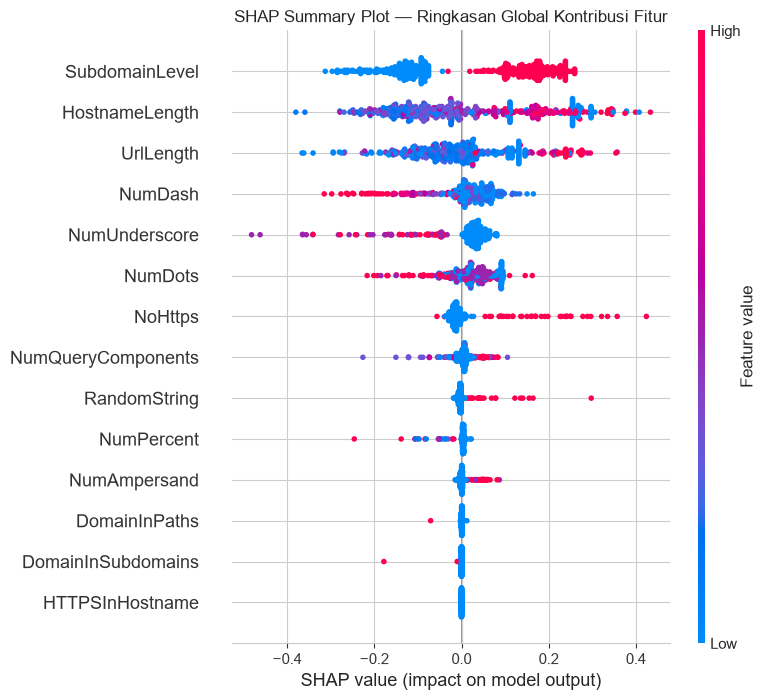

In [20]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_phishing, X_sample, plot_type="dot", show=False)
plt.title("SHAP Summary Plot — Ringkasan Global Kontribusi Fitur")
plt.tight_layout()
plt.show()

**SHAP Bar Plot (Mean |SHAP Value|)** — rata-rata besaran (magnitude) kontribusi absolut tiap fitur terhadap prediksi, tanpa memandang arah pengaruhnya. Semakin panjang batang, semakin besar pengaruh fitur tersebut secara rata-rata terhadap keputusan model.

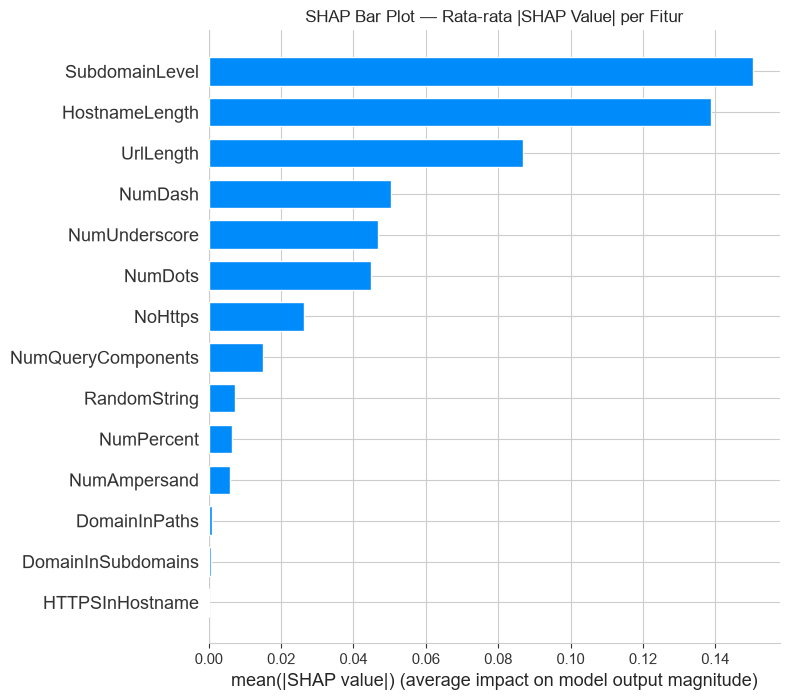

Peringkat fitur berdasarkan rata-rata |SHAP value|:
SubdomainLevel        0.1504
HostnameLength        0.1388
UrlLength             0.0868
NumDash               0.0503
NumUnderscore         0.0469
NumDots               0.0448
NoHttps               0.0264
NumQueryComponents    0.0150
RandomString          0.0073
NumPercent            0.0064
NumAmpersand          0.0060
DomainInPaths         0.0009
DomainInSubdomains    0.0005
HTTPSInHostname       0.0000
Name: Mean |SHAP Value|, dtype: float64


In [21]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values_phishing, X_sample, plot_type="bar", show=False)
plt.title("SHAP Bar Plot — Rata-rata |SHAP Value| per Fitur")
plt.tight_layout()
plt.show()

mean_abs_shap = (
    pd.Series(np.abs(shap_values_phishing).mean(axis=0), index=feature_cols)
    .sort_values(ascending=False)
    .rename("Mean |SHAP Value|")
)
print("Peringkat fitur berdasarkan rata-rata |SHAP value|:")
print(mean_abs_shap.round(4))

**SHAP Beeswarm Plot** — variasi dari summary plot yang menonjolkan kepadatan (density) sebaran nilai SHAP tiap fitur; setiap titik mewakili satu sampel URL, posisinya menunjukkan besar & arah kontribusi (kiri = mendorong ke *Legitimate*, kanan = mendorong ke *Phishing*), sedangkan warna tetap merepresentasikan nilai fitur aslinya.

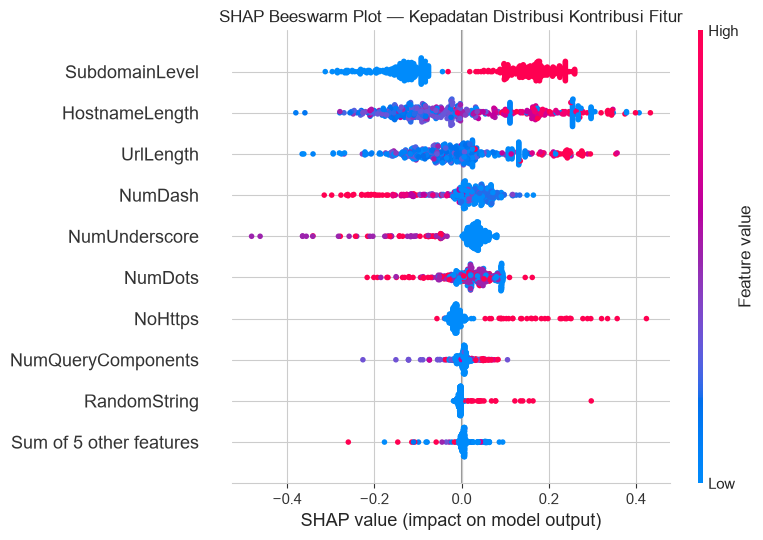

In [22]:
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_explanation, show=False)
plt.title("SHAP Beeswarm Plot — Kepadatan Distribusi Kontribusi Fitur")
plt.tight_layout()
plt.show()

### 6.2 Interpretasi Lokal

**SHAP Waterfall Plot (Per Sampel)** — menjelaskan kontribusi tiap fitur untuk **satu prediksi spesifik**, menjawab pertanyaan *"kenapa URL ini diprediksi sebagai phishing (atau legitimate)?"* secara transparan. Agar interpretasi lokal lebih representatif, waterfall plot ditampilkan untuk **beberapa sampel berbeda**: satu URL *Phishing* yang diprediksi benar, satu URL *Legitimate* yang diprediksi benar, dan (jika tersedia) satu sampel yang **salah diprediksi** (misklasifikasi) sebagai bahan evaluasi kritis model.

Kasus       : Phishing
URL         : https://www.bbc.com/news
Label asli  : Tidak ada pada dataset (diketahui legitimate secara umum)
Prediksi    : Phishing  (P(Phishing) = 0.5693)


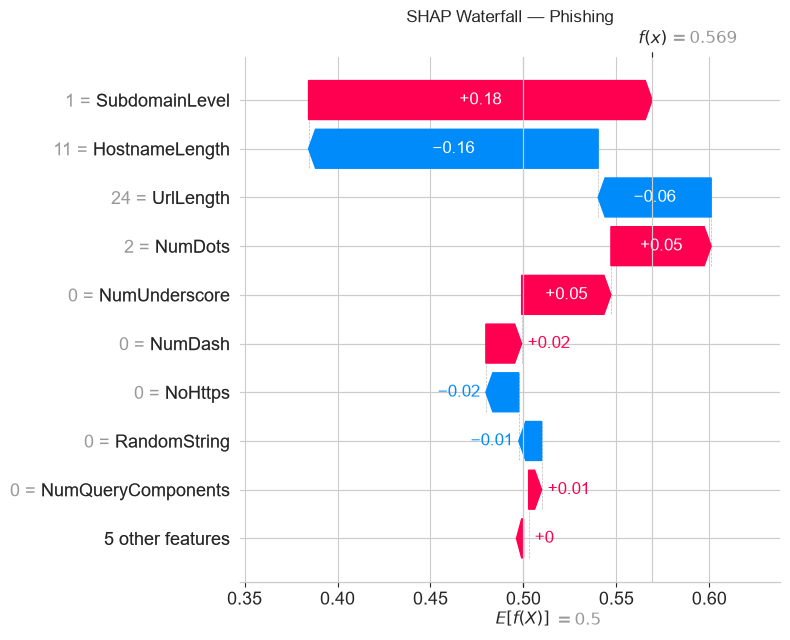

In [24]:
# Studi Kasus: Interpretasi Lokal untuk URL di luar dataset — https://www.bbc.com/news
# (Contoh pengujian model terhadap URL populer/legitimate yang tidak ada di data latih/uji)

target_url = "https://www.bbc.com/news"

# Ekstraksi fitur & prediksi
feats_bbc = extract_features_14(target_url)
X_bbc = pd.DataFrame([feats_bbc])[feature_cols]

pred_bbc = int(model.predict(X_bbc)[0])
proba_bbc = float(model.predict_proba(X_bbc)[0, 1])
pred_label = "Phishing" if pred_bbc == 1 else "Legitimate"

# Cek apakah URL ini memang ada di dataset (untuk label asli/ground truth)
match_bbc = dataset[dataset["url"] == target_url.lower()]
actual_label = (
    "Phishing" if (not match_bbc.empty and match_bbc["label"].iloc[0] == 1)
    else "Legitimate" if not match_bbc.empty
    else "Tidak ada pada dataset (diketahui legitimate secara umum)"
)

# Hitung nilai SHAP untuk URL ini
sv_bbc = explainer.shap_values(X_bbc)
sv_bbc_phishing = sv_bbc[1][0] if isinstance(sv_bbc, list) else sv_bbc[:, :, 1][0]

print("=" * 70)
print(f"Kasus       : {pred_label}")
print(f"URL         : {target_url}")
print(f"Label asli  : {actual_label}")
print(f"Prediksi    : {pred_label}  (P(Phishing) = {proba_bbc:.4f})")

expl_bbc = shap.Explanation(
    values=sv_bbc_phishing,
    base_values=base_value,
    data=X_bbc.iloc[0].values,
    feature_names=feature_cols,
)

plt.figure()
shap.plots.waterfall(expl_bbc, show=False)
plt.title(f"SHAP Waterfall — {pred_label}")
plt.tight_layout()
plt.show()

URL          : https://vxsx3456543.weebly.com/
Label asli   : Phishing
Prediksi     : Phishing  (P(Phishing) = 0.9101)

Kontribusi SHAP per fitur (diurutkan dari paling berpengaruh):
  SubdomainLevel      : nilai=1      SHAP=+0.2101  -> Phishing
  HostnameLength      : nilai=22     SHAP=+0.0767  -> Phishing
  NumUnderscore       : nilai=0      SHAP=+0.0620  -> Phishing
  NumDots             : nilai=2      SHAP=+0.0451  -> Phishing
  NumQueryComponents  : nilai=0      SHAP=+0.0172  -> Phishing
  NoHttps             : nilai=0      SHAP=-0.0145  -> Legitimate
  NumDash             : nilai=0      SHAP=+0.0084  -> Phishing
  RandomString        : nilai=0      SHAP=-0.0041  -> Legitimate
  NumPercent          : nilai=0      SHAP=+0.0040  -> Phishing
  UrlLength           : nilai=31     SHAP=+0.0028  -> Phishing
  NumAmpersand        : nilai=0      SHAP=+0.0015  -> Phishing
  DomainInPaths       : nilai=0      SHAP=+0.0007  -> Phishing
  DomainInSubdomains  : nilai=0      SHAP=+0.0002  -> Phi

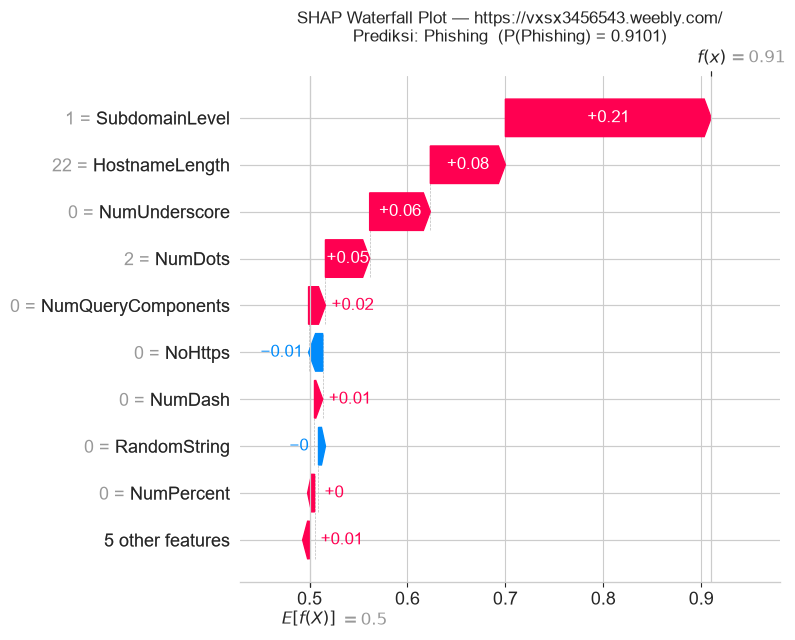

In [26]:
# 6.2 Interpretasi Lokal — Studi Kasus: URL Phishing Spesifik
# Waterfall Plot menelusuri kontribusi tiap fitur dari base value hingga
# probabilitas akhir prediksi, untuk satu sampel URL tertentu.

target_url = "https://vxsx3456543.weebly.com/"

# Ekstraksi fitur & prediksi untuk URL contoh
feats_local = extract_features_14(target_url)
X_local = pd.DataFrame([feats_local])[feature_cols]

pred_local = int(model.predict(X_local)[0])
proba_local = float(model.predict_proba(X_local)[0, 1])
label_local = "Phishing" if pred_local == 1 else "Legitimate"

# Cari label asli (ground truth) apabila URL ini memang berasal dari dataset penelitian
match = dataset[dataset["url"] == target_url.lower()]
actual_label = "Phishing" if (not match.empty and match["label"].iloc[0] == 1) else (
    "Legitimate" if not match.empty else "Tidak ditemukan pada dataset"
)

print("=" * 70)
print(f"URL          : {target_url}")
print(f"Label asli   : {actual_label}")
print(f"Prediksi     : {label_local}  (P(Phishing) = {proba_local:.4f})")

# Hitung nilai SHAP untuk sampel tunggal ini
sv_local = explainer.shap_values(X_local)
sv_local_phishing = sv_local[1][0] if isinstance(sv_local, list) else sv_local[:, :, 1][0]

base_value_local = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

expl_local = shap.Explanation(
    values=sv_local_phishing,
    base_values=base_value_local,
    data=X_local.iloc[0].values,
    feature_names=feature_cols,
)

# Rincian kontribusi tiap fitur, diurutkan dari yang paling berpengaruh
contrib_local = (
    pd.Series(sv_local_phishing, index=feature_cols)
    .sort_values(key=np.abs, ascending=False)
)
print("\nKontribusi SHAP per fitur (diurutkan dari paling berpengaruh):")
for fname, shap_val in contrib_local.items():
    arah = "-> Phishing" if shap_val > 0 else "-> Legitimate"
    print(f"  {fname:20s}: nilai={feats_local[fname]:<6} SHAP={shap_val:+.4f}  {arah}")

# Visualisasi Waterfall Plot (Gambar 10)
plt.figure(figsize=(9, 6))
shap.plots.waterfall(expl_local, show=False)
plt.title(f"SHAP Waterfall Plot — {target_url}\nPrediksi: {label_local}  (P(Phishing) = {proba_local:.4f})")
plt.tight_layout()
plt.show()

Kasus       : Phishing — Prediksi Benar
URL         : https://docs.google.com/presentation/d/e/2PACX-1vR-QYloND8w5LWoEBkvWY7xFAE6BgfzSOcFOVrp7s5W2AtBzJzD7iXQlyP2XAfSpAHcWLGhEU_mHhp1/pub?start=false&amp;loop=false&amp;delayms=3000&amp;slide=id.p
Label asli  : Phishing
Prediksi    : Phishing  (P(Phishing) = 1.0000)


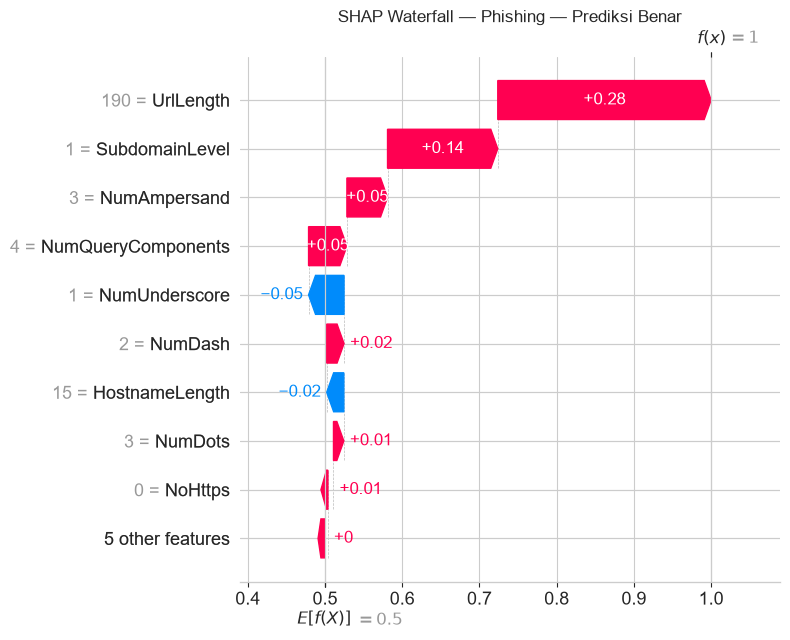

Kasus       : Legitimate — Prediksi Benar
URL         : http://bdnews24.com/business/2015/05/07/government-opening-up-capital-market-to-foreign-mutual-funds
Label asli  : Legitimate
Prediksi    : Legitimate  (P(Phishing) = 0.0000)


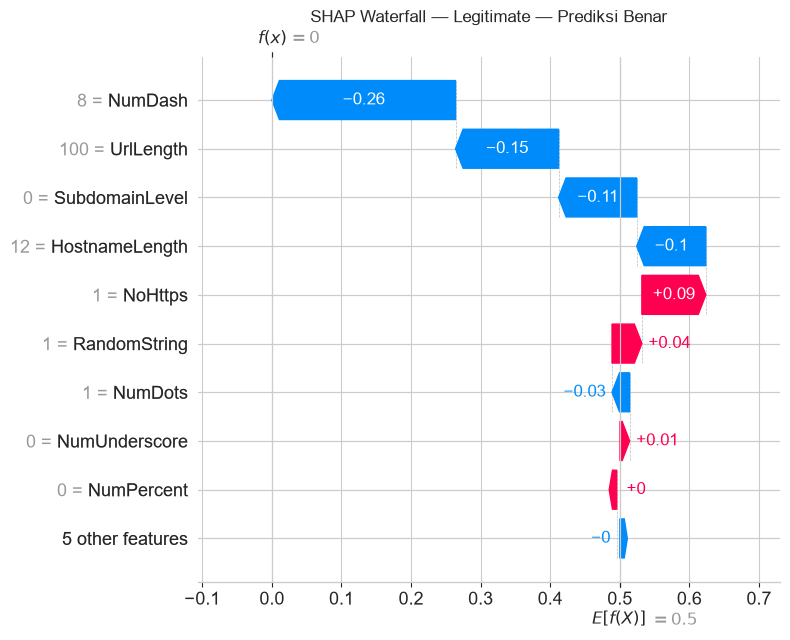

Kasus       : Misklasifikasi
URL         : nme.com/artists/prisoners
Label asli  : Legitimate
Prediksi    : Phishing  (P(Phishing) = 0.5716)


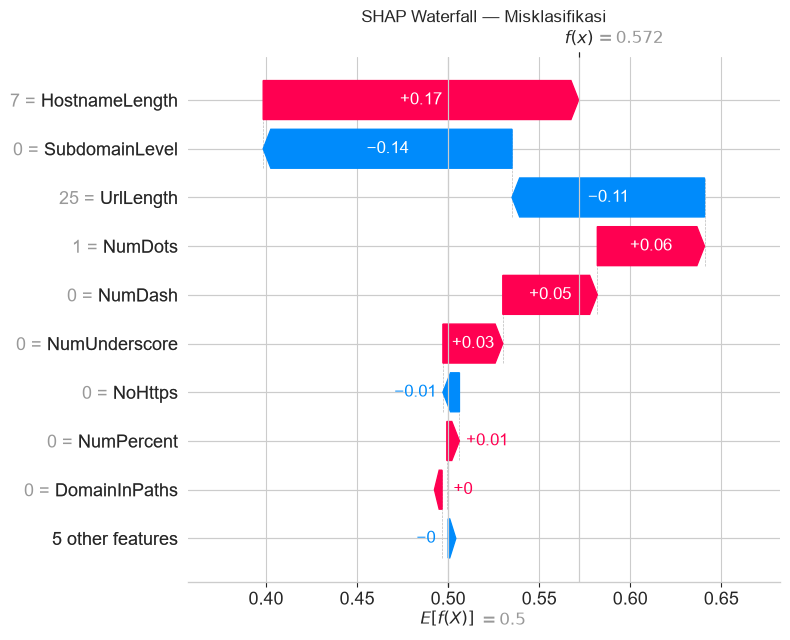

In [27]:
y_pred_sample = model.predict(X_sample)
y_proba_sample = model.predict_proba(X_sample)[:, 1]

sample_meta = pd.DataFrame({
    "actual": y_test.loc[X_sample.index].values,
    "pred": y_pred_sample,
    "proba_phishing": y_proba_sample,
}, index=X_sample.index)

# Pilih sampel representatif:
# 1) Phishing diprediksi benar dengan keyakinan tertinggi
# 2) Legitimate diprediksi benar dengan keyakinan tertinggi
# 3) Sampel misklasifikasi (jika ada)
correct_phishing = sample_meta[(sample_meta["actual"] == 1) & (sample_meta["pred"] == 1)]
correct_legit = sample_meta[(sample_meta["actual"] == 0) & (sample_meta["pred"] == 0)]
misclassified = sample_meta[sample_meta["actual"] != sample_meta["pred"]]

selected_cases = []
if len(correct_phishing) > 0:
    selected_cases.append(("Phishing — Prediksi Benar", correct_phishing["proba_phishing"].idxmax()))
if len(correct_legit) > 0:
    selected_cases.append(("Legitimate — Prediksi Benar", correct_legit["proba_phishing"].idxmin()))
if len(misclassified) > 0:
    selected_cases.append(("Misklasifikasi", misclassified.index[0]))

for case_label, original_idx in selected_cases:
    idx = X_sample.index.get_loc(original_idx)
    sample_url = data_final.loc[original_idx, "url"]
    actual_label = "Phishing" if y_test.loc[original_idx] == 1 else "Legitimate"
    pred_label = "Phishing" if y_pred_sample[idx] == 1 else "Legitimate"

    print("=" * 70)
    print(f"Kasus       : {case_label}")
    print(f"URL         : {sample_url}")
    print(f"Label asli  : {actual_label}")
    print(f"Prediksi    : {pred_label}  (P(Phishing) = {y_proba_sample[idx]:.4f})")

    expl_single = shap.Explanation(
        values=shap_values_phishing[idx],
        base_values=base_value,
        data=X_sample.iloc[idx].values,
        feature_names=feature_cols,
    )

    plt.figure()
    shap.plots.waterfall(expl_single, show=False)
    plt.title(f"SHAP Waterfall — {case_label}")
    plt.tight_layout()
    plt.show()

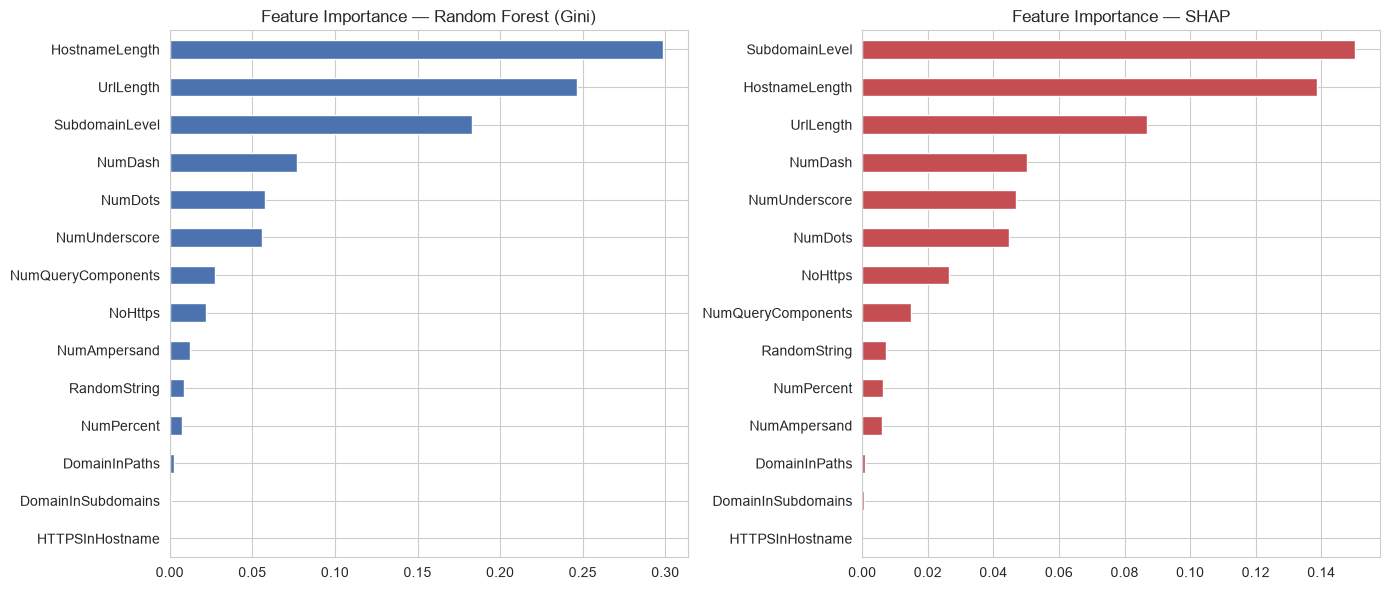

,RF_Gini,SHAP
SubdomainLevel,0.182987,0.150380
HostnameLength,0.298513,0.138808
UrlLength,0.246729,0.086768
NumDash,0.077105,0.050345
NumUnderscore,0.055772,0.046861
NumDots,0.057543,0.044790
NoHttps,0.022207,0.026366
NumQueryComponents,0.027131,0.014960
RandomString,0.008627,0.007278
NumPercent,0.007601,0.006380


In [28]:
rf_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
shap_importance = pd.Series(np.abs(shap_values_phishing).mean(axis=0), index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Feature Importance — Random Forest (Gini)")
shap_importance.sort_values().plot.barh(ax=axes[1], color="#C44E52")
axes[1].set_title("Feature Importance — SHAP")
plt.tight_layout()
plt.show()

pd.DataFrame({"RF_Gini": rf_importance, "SHAP": shap_importance}).sort_values("SHAP", ascending=False)

## Implementasi Pipeline Prediksi + Modul Penjelas SHAP *(Tujuan 3)*

Model terbaik disimpan menggunakan `joblib`, kemudian dibangun pipeline end-to-end yang menerima URL mentah, mengekstrak fitur, menjalankan prediksi, menghitung nilai SHAP, dan **menyusun penjelasan berbahasa natural** atas keputusan model — modul inilah yang menjadi dasar sistem penjelas pada aplikasi web (Bagian 8 & aplikasi Streamlit terlampir pada folder `website_streamlit/`).

In [29]:
joblib.dump(model, "random_forest_phishing_model.joblib")
joblib.dump(feature_cols, "feature_columns.joblib")
print("Model dan daftar fitur berhasil disimpan.")


Model dan daftar fitur berhasil disimpan.


URL        : https://www.bbc.com/news
Prediksi   : Phishing  (probabilitas phishing = 0.5693)

Kenapa URL ini diprediksi Phishing?
  [PHISHING] SubdomainLevel: URL memiliki beberapa level subdomain (1), teknik umum untuk menyerupai domain resmi  (kontribusi SHAP = +0.1848)
  [PHISHING] NumDots: URL memiliki cukup banyak tanda titik (2)  (kontribusi SHAP = +0.0539)
  [PHISHING] NumUnderscore: jumlah underscore pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0480)
  [PHISHING] NumDash: jumlah tanda hubung pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0192)
  [PHISHING] NumQueryComponents: URL membawa cukup banyak parameter query (0)  (kontribusi SHAP = +0.0070)


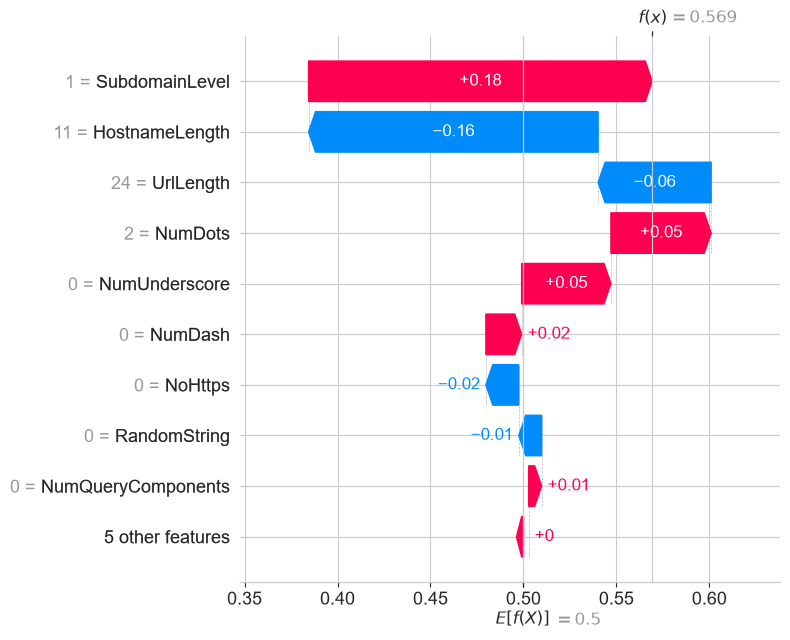

In [30]:
FEATURE_META = {
    "UrlLength":          {"no": 1,  "label": "Panjang URL"},
    "NumDots":            {"no": 2,  "label": "Jumlah Titik (.)"},
    "SubdomainLevel":     {"no": 3,  "label": "Tingkat Subdomain"},
    "NumDash":            {"no": 4,  "label": "Jumlah Tanda Hubung (-)"},
    "NumUnderscore":      {"no": 5,  "label": "Jumlah Underscore (_)"},
    "NumPercent":         {"no": 6,  "label": "Jumlah Persen (%)"},
    "NumQueryComponents": {"no": 7,  "label": "Jumlah Parameter Query"},
    "NumAmpersand":       {"no": 8,  "label": "Jumlah Ampersand (&)"},
    "RandomString":       {"no": 9,  "label": "Indikasi String Acak"},
    "NoHttps":            {"no": 10, "label": "Tanpa HTTPS"},
    "DomainInPaths":      {"no": 11, "label": "Domain Muncul di Path"},
    "DomainInSubdomains": {"no": 12, "label": "Domain Muncul di Subdomain"},
    "HTTPSInHostname":    {"no": 13, "label": "Kata 'https' di Hostname"},
    "HostnameLength":     {"no": 14, "label": "Panjang Hostname"},
}

def build_reason_sentence(fname, value, shap_val):
    """Menyusun kalimat penjelasan XAI berbahasa natural untuk satu fitur."""
    pushes_phishing = shap_val > 0
    v = int(value)
    templates = {
        "UrlLength": (f"URL cukup panjang ({v} karakter), pola yang sering dipakai untuk menyamarkan domain asli",
                       f"panjang URL wajar ({v} karakter)"),
        "NumDots": (f"URL memiliki cukup banyak tanda titik ({v})", f"jumlah tanda titik pada URL wajar ({v})"),
        "SubdomainLevel": (f"URL memiliki beberapa level subdomain ({v}), teknik umum untuk menyerupai domain resmi",
                            f"struktur subdomain URL sederhana ({v} level)"),
        "NumDash": (f"jumlah tanda hubung pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing",
                     f"jumlah tanda hubung pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL legitimate"),
        "NumUnderscore": (f"jumlah underscore pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing",
                           f"jumlah underscore pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL legitimate"),
        "NumPercent": (f"jumlah karakter encoding '%' pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing",
                        f"jumlah karakter encoding '%' pada URL ini ({v}) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL legitimate"),
        "NumQueryComponents": (f"URL membawa cukup banyak parameter query ({v})", f"jumlah parameter query wajar ({v})"),
        "NumAmpersand": (f"URL memiliki beberapa simbol '&' ({v})", f"jumlah simbol '&' wajar ({v})"),
        "RandomString": ("nama domain terindikasi berupa string acak (mirip hasil generate otomatis)",
                          "nama domain tidak menyerupai string acak"),
        "NoHttps": ("URL tidak menggunakan protokol HTTPS yang aman", "URL sudah menggunakan protokol HTTPS"),
        "DomainInPaths": (f"nama domain muncul kembali pada path URL ({v}), pola yang teridentifikasi pada dataset penelitian",
                           f"nama domain tidak diulang secara mencurigakan pada path URL ({v})"),
        "DomainInSubdomains": ("nama domain resmi disisipkan sebagai subdomain, pola khas phishing",
                                "tidak ditemukan penyisipan nama domain pada subdomain"),
        "HTTPSInHostname": ("kata 'https' disisipkan di dalam hostname agar URL terlihat aman secara visual",
                             "tidak ditemukan kata 'https' yang disisipkan mencurigakan pada hostname"),
        "HostnameLength": (f"hostname URL cukup panjang ({v} karakter)", f"panjang hostname wajar ({v} karakter)"),
    }
    high_text, low_text = templates.get(fname, (f"nilai fitur {fname} tinggi", f"nilai fitur {fname} wajar"))
    return high_text if pushes_phishing else low_text


def predict_url(url, trained_model=model, top_n=5, plot=True):
    """
    Modul penjelas SHAP: pipeline end-to-end URL mentah -> label + probabilitas
    + daftar alasan utama (Tujuan 2 & 3).
    """
    feats = extract_features_14(url)
    X_row = pd.DataFrame([feats])[feature_cols]

    pred = int(trained_model.predict(X_row)[0])
    proba = float(trained_model.predict_proba(X_row)[0, 1])
    label = "Phishing" if pred == 1 else "Legitimate"

    sv = explainer.shap_values(X_row)
    sv_phish = sv[1][0] if isinstance(sv, list) else sv[:, :, 1][0]

    contributions = []
    for fname, shap_val in zip(feature_cols, sv_phish):
        contributions.append({
            "feature": fname, "value": feats[fname], "shap": float(shap_val),
            "direction": "phishing" if shap_val > 0 else "legitimate",
            "reason": build_reason_sentence(fname, feats[fname], shap_val),
        })
    contributions_sorted = sorted(contributions, key=lambda c: abs(c["shap"]), reverse=True)
    top_reasons = [c for c in contributions_sorted if c["direction"] == label.lower()][:top_n]

    print(f"URL        : {url}")
    print(f"Prediksi   : {label}  (probabilitas phishing = {proba:.4f})")
    print(f"\nKenapa URL ini diprediksi {label}?")
    for r in top_reasons:
        icon = "[PHISHING]" if r["direction"] == "phishing" else "[LEGITIMATE]"
        fname_r = r["feature"]; reason_r = r["reason"]; shap_r = r["shap"]
        print(f"  {icon} {fname_r}: {reason_r}  (kontribusi SHAP = {shap_r:+.4f})")

    if plot:
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
        expl_local = shap.Explanation(values=sv_phish, base_values=base_value,
                                       data=X_row.iloc[0].values, feature_names=feature_cols)
        plt.figure()
        shap.plots.waterfall(expl_local, show=False)
        plt.tight_layout()
        plt.show()

    return {"url": url, "label": label, "proba_phishing": proba, "top_reasons": top_reasons}


# Contoh pemakaian: menjawab "kenapa URL ini phishing?" secara eksplisit
_ = predict_url("https://www.bbc.com/news")

URL        : http://secure-login-update.tk/verify/account?id=12345&token=x
Prediksi   : Phishing  (probabilitas phishing = 0.5014)

Kenapa URL ini diprediksi Phishing?
  [PHISHING] NoHttps: URL tidak menggunakan protokol HTTPS yang aman  (kontribusi SHAP = +0.1994)
  [PHISHING] NumUnderscore: jumlah underscore pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0173)
  [PHISHING] NumPercent: jumlah karakter encoding '%' pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0131)
  [PHISHING] UrlLength: URL cukup panjang (61 karakter), pola yang sering dipakai untuk menyamarkan domain asli  (kontribusi SHAP = +0.0090)
  [PHISHING] HostnameLength: hostname URL cukup panjang (22 karakter)  (kontribusi SHAP = +0.0080)


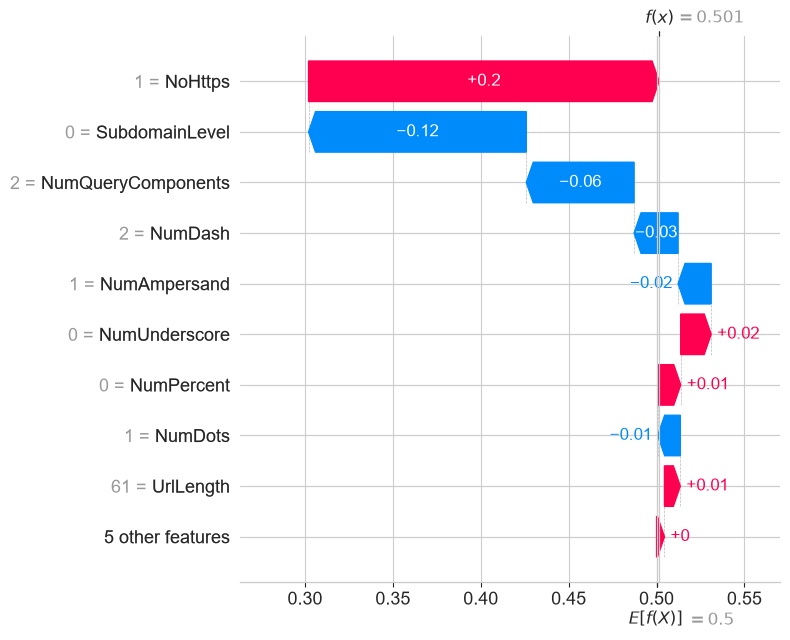

In [33]:
# Contoh kedua: URL dengan kata kunci mencurigakan tetapi struktur sederhana (Sub-bab 4.5.2)
_ = predict_url("http://secure-login-update.tk/verify/account?id=12345&token=x")

## Pengujian Sistem (Black-Box Testing) *(Tujuan 3)*

Pipeline model + modul penjelas SHAP diuji melalui empat skenario *black-box testing* untuk memastikan sistem dapat digunakan secara praktis dan andal.

In [34]:
print("=== (1) & (2) Uji Prediksi Tunggal & Batch ===")
test_urls = [
    "https://www.bbc.com/news",
    "https://www.tokopedia.com",
    "http://update-account-security-paypal.net/login",
    "http://verify-appleid.billing-confirmation.com",
    "http://klikbca-login-verifikasidata.com",
]
for u in test_urls:
    r = predict_url(u, plot=False)
    print("-" * 60)

=== (1) & (2) Uji Prediksi Tunggal & Batch ===
URL        : https://www.bbc.com/news
Prediksi   : Phishing  (probabilitas phishing = 0.5693)

Kenapa URL ini diprediksi Phishing?
  [PHISHING] SubdomainLevel: URL memiliki beberapa level subdomain (1), teknik umum untuk menyerupai domain resmi  (kontribusi SHAP = +0.1848)
  [PHISHING] NumDots: URL memiliki cukup banyak tanda titik (2)  (kontribusi SHAP = +0.0539)
  [PHISHING] NumUnderscore: jumlah underscore pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0480)
  [PHISHING] NumDash: jumlah tanda hubung pada URL ini (0) sesuai pola yang pada dataset penelitian lebih sering ditemukan pada URL phishing  (kontribusi SHAP = +0.0192)
  [PHISHING] NumQueryComponents: URL membawa cukup banyak parameter query (0)  (kontribusi SHAP = +0.0070)
------------------------------------------------------------
URL        : https://www.tokopedia.com
Prediksi   : Phishing  (probabilita

In [35]:
print("=== (3) Uji Ketahanan terhadap Input Tidak Valid ===")
edge_case_urls = ["", "bukan_url_yang_valid", "ftp://192.168.1.1/file", "http://", "a" * 500]

for u in edge_case_urls:
    try:
        feats = extract_features_14(u)
        pred = model.predict(pd.DataFrame([feats])[feature_cols])[0]
        status = "BERHASIL diproses"
        label = "Phishing" if pred == 1 else "Legitimate"
    except Exception as e:
        status = f"GAGAL: {e}"
        label = "-"
    display_url = (u[:40] + "...") if len(u) > 40 else (u if u else "(string kosong)")
    print(f"Input: {display_url:45s} | Status: {status:20s} | Prediksi: {label}")

=== (3) Uji Ketahanan terhadap Input Tidak Valid ===
Input: (string kosong)                               | Status: BERHASIL diproses    | Prediksi: Legitimate
Input: bukan_url_yang_valid                          | Status: BERHASIL diproses    | Prediksi: Legitimate
Input: ftp://192.168.1.1/file                        | Status: BERHASIL diproses    | Prediksi: Legitimate
Input: http://                                       | Status: BERHASIL diproses    | Prediksi: Phishing
Input: aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...   | Status: BERHASIL diproses    | Prediksi: Legitimate


In [36]:
print("=== (4) Uji Konsistensi Model Tersimpan vs Model Asli ===")
loaded_model = joblib.load("random_forest_phishing_model.joblib")

sample_check = X_test.sample(n=300, random_state=1)
pred_original = model.predict(sample_check)
pred_loaded = loaded_model.predict(sample_check)

is_consistent = np.array_equal(pred_original, pred_loaded)
print("Prediksi model asli dan model yang dimuat ulang konsisten (n=300):", is_consistent)

=== (4) Uji Konsistensi Model Tersimpan vs Model Asli ===
Prediksi model asli dan model yang dimuat ulang konsisten (n=300): True
